In [1]:
from pathlib import Path
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent

train = pd.read_csv(root / "data" / "raw" / "train.csv")


In [3]:
numerical_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]
features = numerical_features + categorical_features

x = train[features]
y = train["Survived"]

x_train, x_valid, y_train, y_valid = train_test_split(
    x, 
    y, 
    test_size=0.20, 
    stratify=y,
    random_state=42,
)

In [4]:
numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("importer", numerical_pipeline, numerical_features),
    ("encoder", categorical_pipeline, categorical_features)
])

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000)),
])

model.fit(x_train, y_train)
predictions = model.predict(x_valid)

majority_class = y_train.mode().iat[0]
dummy_accuracy = (y_valid == majority_class).mean()
model_accuracy = accuracy_score(y_valid, predictions)

In [5]:
print(f"Dummy accuracy: {dummy_accuracy:.3f}")
print(f"Logistic Regression accuracy: {model_accuracy:.3f}")
print(f"Improvement: {model_accuracy - dummy_accuracy:+.3f}")

Dummy accuracy: 0.615
Logistic Regression accuracy: 0.804
Improvement: +0.190


## Result

Logistic Regression achieved **0.804** validation accuracy, improving 
by **+0.190** over the majority baseline. The comparison uses the 
same stratified split, making the result fair.

In [6]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

cv_scores = cross_val_score(
    model,
    x,
    y,
    cv=cv,
    scoring="accuracy",
)

for fold, score in enumerate(cv_scores, start=1):
    print(f"Fold {fold}: {score:.3f}")

print(f"CV mean: {cv_scores.mean():.3f}")
print(f"CV std : {cv_scores.std():.3f}")

Fold 1: 0.782
Fold 2: 0.803
Fold 3: 0.798
Fold 4: 0.781
Fold 5: 0.820
CV mean: 0.797
CV std : 0.015


## Cross-validation

Five-fold stratified cross-validation achieved a mean accuracy of **0.797**
with a standard deviation of **0.015**. This measures how stable the model is
across different subsets of passengers.

              precision    recall  f1-score   support

Not survived      0.810     0.891     0.848       110
    Survived      0.793     0.667     0.724        69

    accuracy                          0.804       179
   macro avg      0.802     0.779     0.786       179
weighted avg      0.803     0.804     0.801       179

False negatives: 23
False positives: 12


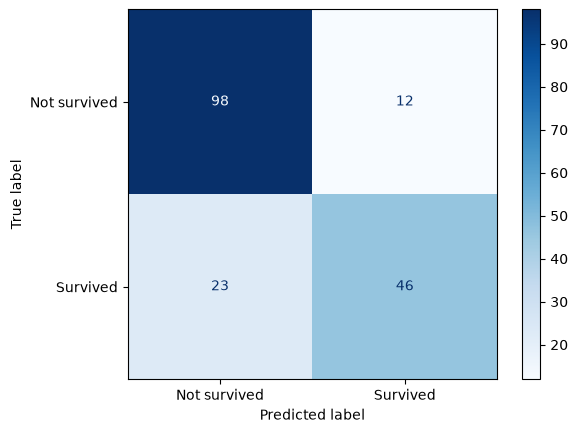

In [7]:
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
)

cm = confusion_matrix(y_valid, predictions)
tn, fp, fn, tp = cm.ravel()

print(classification_report(
    y_valid,
    predictions,
    target_names=["Not survived", "Survived"],
    digits=3,
))
print(f"False negatives: {fn}")
print(f"False positives: {fp}")

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not survived", "Survived"],
).plot(cmap="Blues");

## Error analysis

- The model missed **23** passengers who actually survived.
- Survivor recall is **0.667**, meaning the model identified **66.7%** of all actual survivors.
- False negatives (**23**) are higher than false positives (**12**). On this validation set, the model more often classified survivors as not surviving than the reverse.

In [9]:
engineered_train = train.copy()

engineered_train["FamilySize"] = (
    engineered_train["SibSp"]
    + engineered_train["Parch"]
    + 1
)
engineered_train["IsAlone"] = (
    engineered_train["FamilySize"] == 1
).astype(int)

engineered_numerical_features = [
    "Age",
    "Fare",
    "FamilySize",
    "IsAlone",
]
engineered_features = (
    engineered_numerical_features
    + categorical_features
)

x_engineered = engineered_train[engineered_features]

engineered_preprocessor = ColumnTransformer([
    (
        "numerical",
        numerical_pipeline,
        engineered_numerical_features,
    ),
    (
        "categorical",
        categorical_pipeline,
        categorical_features,
    ),
])

engineered_model = Pipeline([
    ("preprocessor", engineered_preprocessor),
    (
        "classifier",
        LogisticRegression(max_iter=1000),
    ),
])

engineered_cv_scores = cross_val_score(
    engineered_model,
    x_engineered,
    y,
    cv=cv,
    scoring="accuracy",
)

baseline_mean = cv_scores.mean()
engineered_mean = engineered_cv_scores.mean()
delta = engineered_mean - baseline_mean

In [10]:
print(f"Baseline CV mean  : {baseline_mean:.3f}")
print(f"Engineered CV mean: {engineered_mean:.3f}")
print(f"Engineered CV std : {engineered_cv_scores.std():.3f}")
print(f"Delta             : {delta:+.3f}")

Baseline CV mean  : 0.797
Engineered CV mean: 0.802
Engineered CV std : 0.015
Delta             : +0.006


## Family feature experiment

- Baseline 5-fold CV mean: **0.797**
- Engineered 5-fold CV mean: **0.802**
- Engineered CV standard deviation: **0.015**
- Delta: **+0.006**
- Decision: **keep `FamilySize` and `IsAlone`** for the next model because the improvement exceeds the `+0.005` rule. The gain is modest, so it still needs competition validation.

In [11]:
test = pd.read_csv(
    root / "data" / "raw" / "test.csv"
)

test_engineered = test.copy()
test_engineered["FamilySize"] = (
    test_engineered["SibSp"]
    + test_engineered["Parch"]
    + 1
)
test_engineered["IsAlone"] = (
    test_engineered["FamilySize"] == 1
).astype(int)

x_full = engineered_train[engineered_features]
x_test = test_engineered[engineered_features]

engineered_model.fit(x_full, y)
test_predictions = engineered_model.predict(x_test)

submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": test_predictions.astype(int),
})

assert submission.shape == (418, 2)
assert submission["PassengerId"].equals(
    test["PassengerId"]
)
assert set(
    submission["Survived"].unique()
).issubset({0, 1})
assert not submission.isna().any().any()

submission_dir = root / "submissions"
submission_dir.mkdir(parents=True, exist_ok=True)

submission_path = (
    submission_dir / "logistic_family.csv"
)
submission.to_csv(submission_path, index=False)

In [12]:
print(f"Submission shape: {submission.shape}")
print(f"Missing values: {submission.isna().sum().sum()}")
print(f"Saved to: {submission_path}")
print(submission["Survived"].value_counts().sort_index())

Submission shape: (418, 2)
Missing values: 0
Saved to: /home/mrr/projects/titanic-ml-baseline/submissions/logistic_family.csv
Survived
0    261
1    157
Name: count, dtype: int64


## Competition submission

- Submission: `logistic-family-v1`
- Model: Logistic Regression with `FamilySize` and `IsAlone`
- Public Kaggle accuracy: **0.76794**
- Local 5-fold CV mean: **0.802**
- The public score is approximately **0.034** below local CV. This does not prove overfitting, but shows why local validation and competition results must both be tracked.